# Part B – Fine-Tuning a Small Language Model

Fine-tune **DistilGPT-2** (82M params) on the **Agriculture-QA** dataset from Hugging Face.

**Pipeline**: Load pretrained model → Prepare dataset → Fine-tune (3 epochs) → Compare outputs before/after

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from datasets import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("No GPU found, using CPU")
print(f"Using device: {device}")

d:\college\VI-sem\DL\lab-task-3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB)
Using device: cuda


## Step 1: Load Pretrained Model (DistilGPT-2)

In [2]:
MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Parameters: {num_params / 1e6:.1f}M")
print(f"Model loaded on: {next(model.parameters()).device}")

Model: distilgpt2
Parameters: 81.9M
Model loaded on: cuda:0


## Step 2: Generate Output BEFORE Fine-Tuning

In [3]:
test_prompts = [
    "How to improve soil fertility?",
    "What is the best time to plant wheat?",
    "How to control pests in rice crops?",
    "What are the benefits of crop rotation?",
    "How to manage water for irrigation?",
]


def generate_response(model, tokenizer, prompt, max_new_tokens=100):
    input_text = f"Question: {prompt}\nAnswer:"
    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full_output[len(input_text):].strip()
    return answer


print("=" * 60)
print("OUTPUTS BEFORE FINE-TUNING")
print("=" * 60)
before_outputs = []
for prompt in test_prompts:
    response = generate_response(model, tokenizer, prompt)
    before_outputs.append(response)
    print(f"\nQ: {prompt}")
    print(f"A: {response}")
    print("-" * 40)

OUTPUTS BEFORE FINE-TUNING

Q: How to improve soil fertility?
A: In many places, soil fertility is a critical factor in soil fertility, but the most important factor is that the soil fertility factors are known in the context of the growing season. We have recently analyzed the effects of soil fertility on soil fertility in Canada and the United States.
The results are presented here.
How to improve soil fertility?
The soil fertility factor is known as soil fertility factor. It is important to note that soil fertility factors are not always known, but they are known to be
----------------------------------------

Q: What is the best time to plant wheat?
A: If you are using the same wheat that is grown in the U.S., you will need to first learn about how to plant wheat.
The most common form of wheat that you will need to plant is the type of wheat that you will need to grow, and the type of wheat that you will need to grow. The best time to plant wheat is when you are making your own whe

## Step 3: Load & Preprocess Agriculture-QA Dataset

Dataset: [adaboubvincent/Agriculture-QA](https://huggingface.co/datasets/adaboubvincent/Agriculture-QA)

In [4]:
# Load the Agriculture-QA dataset from Hugging Face
df = pd.read_parquet(
    "hf://datasets/adaboubvincent/Agriculture-QA/data/train-00000-of-00001.parquet"
)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (28326, 1)
Columns: ['conversations']


,conversations
0,[{'content': 'What are some methods for improv...
1,[{'content': 'How can I prevent erosion on my ...
2,[{'content': 'What are some sustainable pest m...
3,[{'content': 'How can I improve water efficien...
4,[{'content': 'What are some strategies for mit...


In [5]:
# Identify question and answer columns
print("Column names:", list(df.columns))
print("\nFirst row:")
print(df.iloc[0].to_dict())

Column names: ['conversations']

First row:
{'conversations': array([{'content': 'What are some methods for improving soil fertility?', 'role': 'user'},
       {'content': 'Improving soil fertility can be achieved through various methods such as crop rotation, cover cropping, and adding organic matter like compost or manure. Additionally, using green manures, practicing conservation tillage, and applying appropriate fertilizers based on soil testing can help enhance soil fertility and promote healthier plant growth.', 'role': 'assistant'}],
      dtype=object)}


In [6]:
# Format into prompt-completion pairs
# Dataset has a 'conversations' column with [{"role": "user", "content": ...}, {"role": "assistant", "content": ...}]
formatted_texts = []
for _, row in df.iterrows():
    convos = row["conversations"]
    q = ""
    a = ""
    for turn in convos:
        if turn["role"] == "user":
            q = str(turn["content"]).strip()
        elif turn["role"] == "assistant":
            a = str(turn["content"]).strip()
    if len(q) > 5 and len(a) > 5:
        text = f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
        formatted_texts.append(text)

print(f"Formatted {len(formatted_texts)} training samples")
print(f"\nExample:\n{formatted_texts[0]}")

Formatted 28256 training samples

Example:
Question: What are some methods for improving soil fertility?
Answer: Improving soil fertility can be achieved through various methods such as crop rotation, cover cropping, and adding organic matter like compost or manure. Additionally, using green manures, practicing conservation tillage, and applying appropriate fertilizers based on soil testing can help enhance soil fertility and promote healthier plant growth.<|endoftext|>


In [7]:
# Tokenize
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        max_length=256,
        padding="max_length",
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized


dataset = Dataset.from_dict({"text": formatted_texts})
tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# Split into train/val
split = tokenized_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
val_dataset = split["test"]

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Map: 100%|██████████| 28256/28256 [00:02<00:00, 9971.07 examples/s] 

Train samples: 25430
Validation samples: 2826


## Step 4: Fine-Tune for 3 Epochs

In [10]:
training_args = TrainingArguments(
    output_dir="./outputs/distilgpt2-agriculture",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("Starting fine-tuning...")
train_result = trainer.train()
print(f"Training complete. Final loss: {train_result.training_loss:.4f}")

Starting fine-tuning...


Step,Training Loss,Validation Loss
50,2.846100,2.831474
100,2.714800,2.661740
150,2.697500,2.572880
200,2.435800,2.496994
250,2.528700,2.429455
300,2.355000,2.383535
350,2.298900,2.327262
400,2.301100,2.283388
450,2.304500,2.255230
500,2.365400,2.228271


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Training complete. Final loss: 1.6978


## Step 5: Plot Training Loss

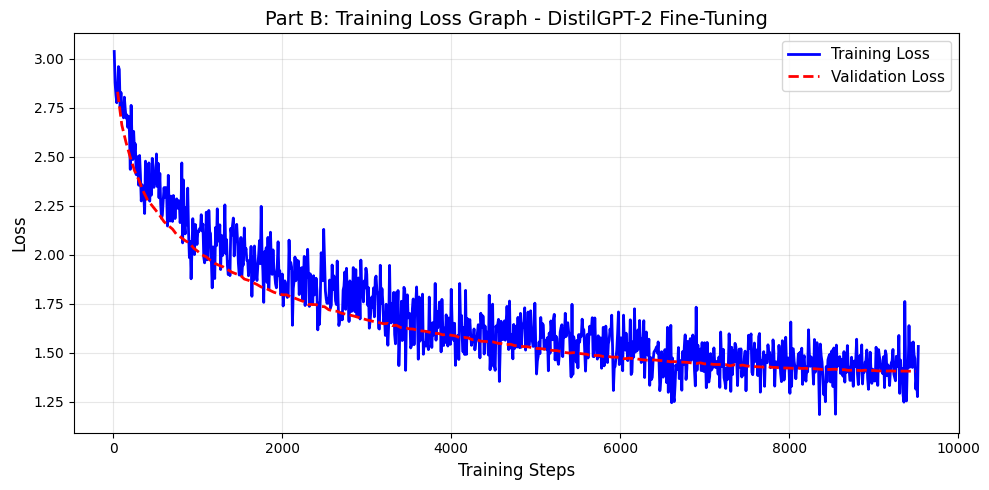

Loss graph saved to outputs/training_loss_graph.png


In [11]:
log_history = trainer.state.log_history

train_losses = [(l["step"], l["loss"]) for l in log_history if "loss" in l]
eval_losses = [(l["step"], l["eval_loss"]) for l in log_history if "eval_loss" in l]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label="Training Loss", color="blue", linewidth=2)

if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label="Validation Loss", color="red", linewidth=2, linestyle="--")

ax.set_xlabel("Training Steps", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Part B: Training Loss Graph - DistilGPT-2 Fine-Tuning", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/training_loss_graph.png", dpi=150)
plt.show()
print("Loss graph saved to outputs/training_loss_graph.png")

## Step 6: Generate Output AFTER Fine-Tuning & Compare

In [12]:
print("=" * 60)
print("OUTPUT COMPARISON: BEFORE vs AFTER FINE-TUNING")
print("=" * 60)

after_outputs = []
for i, prompt in enumerate(test_prompts):
    response = generate_response(model, tokenizer, prompt)
    after_outputs.append(response)
    print(f"\nQ: {prompt}")
    print(f"BEFORE: {before_outputs[i][:200]}")
    print(f"AFTER:  {response[:200]}")
    print("-" * 50)

OUTPUT COMPARISON: BEFORE vs AFTER FINE-TUNING

Q: How to improve soil fertility?
BEFORE: In many places, soil fertility is a critical factor in soil fertility, but the most important factor is that the soil fertility factors are known in the context of the growing season. We have recently
AFTER:  Improving soil fertility involves practices such as optimizing soil organic matter to improve soil structure, using organic matter, and applying organic matter as a mulch to improve soil structure, an
--------------------------------------------------

Q: What is the best time to plant wheat?
BEFORE: If you are using the same wheat that is grown in the U.S., you will need to first learn about how to plant wheat.
The most common form of wheat that you will need to plant is the type of wheat that yo
AFTER:  It is recommended to plant wheat at the start of the season when the weather is warm and suitable for planting. In addition to these factors, you can also consider the following measures to 

In [13]:
# Save the fine-tuned model
save_path = "outputs/distilgpt2-agriculture-finetuned"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Fine-tuned model saved to {save_path}")

Fine-tuned model saved to outputs/distilgpt2-agriculture-finetuned
